# ARIMA BEST & Random Forest

## 1. Imports

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from hydrosense.interface.main import load_data


## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.



**Pris en charge par function la fonction** `load_data`

In [47]:
df = load_data('../data/piezo_bourdet_clean.csv')
df.head()


⭐️ Use case: load_data
✅ load_data() done — 11807 rows | 1994-02-01 → 2026-05-30



,niveau_nappe_eau
date_mesure,
1994-02-01,13.45
1994-02-02,13.55
1994-02-03,13.79
1994-02-04,13.80
1994-02-05,13.79


### Rééchantillonnage mensuel & découpage Train/Test

Les données brutes sont journalières. On les agrège à la **maille mensuelle** (moyenne) pour :
- Réduire le bruit quotidien
- Aligner avec les modèles hydrologiques saisonniers

Le **folding** isole les **12 derniers mois** (juin 2025 → mai 2026) comme jeu de validation.
Le modèle ne voit jamais ces données pendant l'entraînement — c'est ce qui garantit une évaluation honnête.

In [48]:
from hydrosense.ml_logic.folding import get_folds

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

y_mensuel = df.resample('ME').mean()
print(y_mensuel.head())


# TRAIN / TEST SPLIT
# Split qui termine en mars 2025

from hydrosense.interface.main import split_data


# split_data(y_mensuel) ne marche pas - 2026 pour comparer avec Romain
# puis on fixe 2025

TRAIN_END  = "2025-02-28"
TEST_START = "2025-03-01"
TEST_END   = "2025-05-31"
y_mensuel= y_mensuel.iloc[y_mensuel.index < TRAIN_END]
y_test = y_mensuel.iloc[(y_mensuel.index > TEST_START) & (y_mensuel.index <= TEST_END)]

# ==========================================
# TRAIN / VAL Folding

splits = get_folds(y_mensuel.index, n_splits=10, min_train_years=3 , val_months_duration= 3)

             niveau_nappe_eau
date_mesure                  
1994-02-28          13.602857
1994-03-31          12.908065
1994-04-30          12.849000
1994-05-31          12.503871
1994-06-30          11.899333


## 4. XGBoost — Feature Engineering

Le **Random Forest** n'est pas un modèle de séries temporelles natif : il ne comprend pas
la notion de temps. On lui fournit donc des **features de lag** (décalages temporels) :

| Feature | Signification |
|---|---|
| `lag_1` | Niveau du mois précédent |
| `lag_2` | Niveau il y a 2 mois |
| `lag_3` | Niveau il y a 3 mois |
| `lag_12` | Niveau il y a 12 mois (même saison l'an dernier) |
| `mois` | Numéro du mois (saisonnalité) |
| `moyenne_3m` | Tendance récente sur 3 mois |
| `moyenne_6m` | Tendance moyen terme sur 6 mois |

On transforme ainsi un problème temporel en problème de **régression supervisée classique**.

### 4.1 Data lagging mensuel + Folding 

In [ ]:
from hydrosense.interface.main import load_data, evaluate, evaluate_deeper, preprocess, train
from hydrosense.ml_logic.folding import get_folds
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.database.bigquery import load_piezo_bq
from hydrosense import params


DATA_CODE_PIEZO = "BSS001QHYH"
# df = clean_piezo(load_piezo_bq(DATA_CODE_PIEZO))
df  = load_data(DATA_CODE_PIEZO)

if params.DATE_COL in df.columns:
    df[params.DATE_COL] = pd.to_datetime(df[params.DATE_COL])
    df.set_index(params.DATE_COL, inplace=True)
df = df.sort_index()

df_ml = preprocess(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_ml)

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=25, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# 3. Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)
print(metrics)

BSS001QHYH : 14532 lignes chargées
Trou de 224 jours détecté ! 2751 lignes supprimées.
DataFrame final : 1994-01-18 00:00:00 → 2026-05-30 00:00:00 | 11821 jours

⭐️ Use case: preprocess
✅ preprocess() done — 377 mois | 8 colonnes



NameError: name 'split_data' is not defined

In [50]:
cv_metrics, cv_predictions = evaluate_deeper(X_train_df, y_train_df, splits_ml, X_test_df, y_test_df)


⭐️ Evaluate_deeper (Cross-Validation)

--- Fold 1/24 ---
Debug: Current fold 1
Debug: len(X_df) = 362
Debug: len(train_idx) = 74
Debug: max(train_idx) = 73
Model initialized

Training model...
✅ Model trained on 74 rows in 0.55s
   Train MAE  : 0.0058
   Train RMSE : 0.0075

Evaluating model on 74 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 1 | Train MAE: 0.006 | Val MAE: 0.280 | Test MAE: 0.067
  Fold 1 | Train RMSE: 0.007 | Val RMSE: 0.368 | Test RMSE: 0.081
  Fold 1 | Train RMSSE: 0.0069 | Val RMSSE: 0.3354 | Test RMSSE: 0.0741

--- Fold 2/24 ---
Debug: Current fold 2
Debug: len(X_df) = 362
Debug: len(train_idx) = 86
Debug: max(train_idx) = 85
Model initialized

Training model...
✅ Model trained on 86 rows in 1.56s
   Train MAE  : 0.0062
   Train RMSE : 0.0082

Evaluating model on 86 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 2 | Train MAE: 0.006 | Val MAE: 0.173 | Test MAE: 0.091
  Fold 2 | Train RMSE: 0.008 | Val 

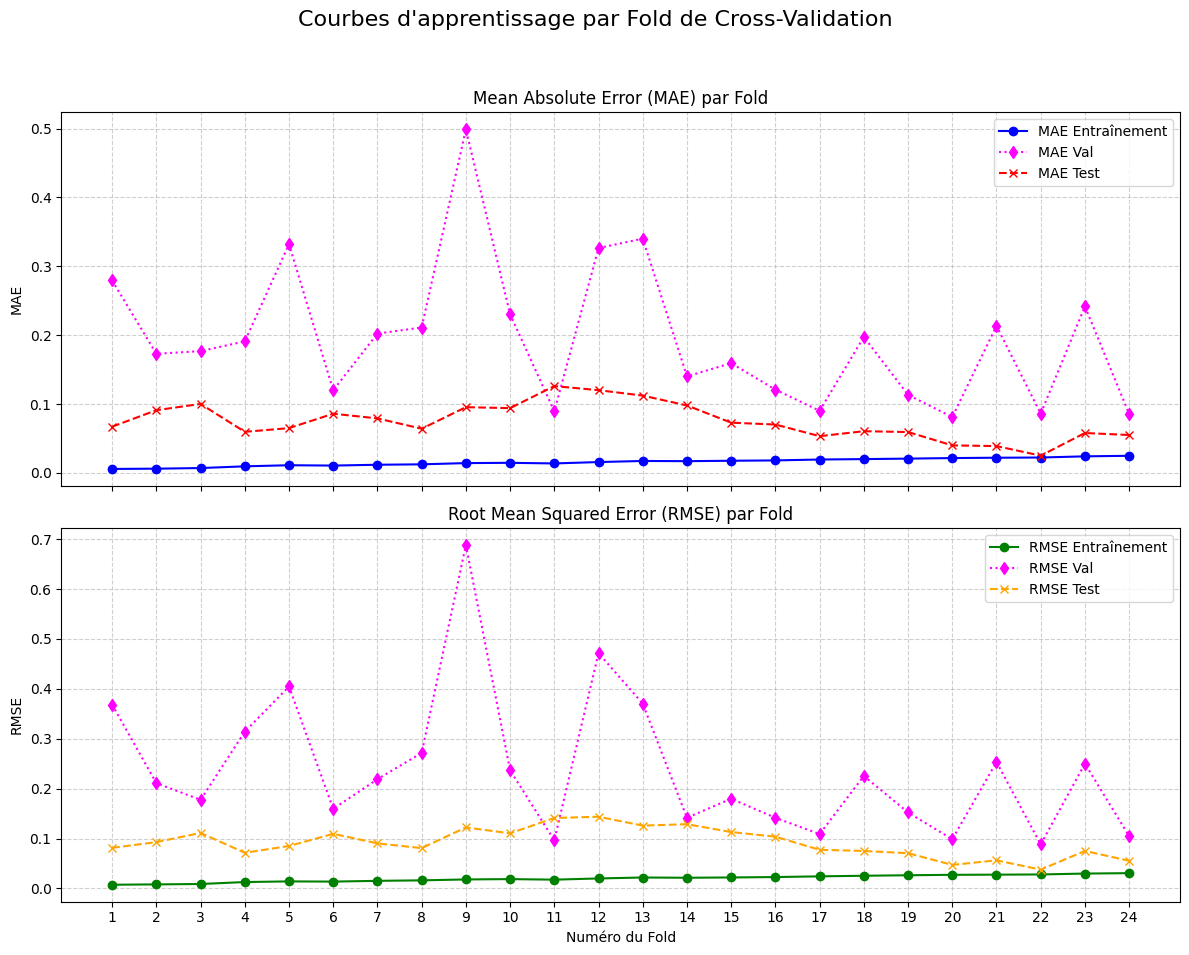

✅ Courbes d'apprentissage affichées.



In [61]:
def plot_learning_curves(cv_metrics: pd.DataFrame):
    """
    Affiche les courbes d'apprentissage (MAE et RMSE) pour les métriques d'entraînement et de test
    obtenues via la cross-validation.
    """

    if not cv_metrics.empty:
        folds = cv_metrics['fold']

        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        fig.suptitle('Courbes d\'apprentissage par Fold de Cross-Validation', fontsize=16)

        # Plot MAE
        axes[0].plot(folds, cv_metrics['mae_train'], marker='o', linestyle='-', label='MAE Entraînement', color='blue')
        axes[0].plot(folds, cv_metrics['mae_val'], marker='d', linestyle=':', label='MAE Val', color='magenta')
        axes[0].plot(folds, cv_metrics['mae_test'], marker='x', linestyle='--', label='MAE Test', color='red')
        axes[0].set_ylabel('MAE')
        axes[0].set_title('Mean Absolute Error (MAE) par Fold')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Plot RMSE (qui est la racine carrée du MSE)
        axes[1].plot(folds, cv_metrics['rmse_train'], marker='o', linestyle='-', label='RMSE Entraînement', color='green')
        axes[1].plot(folds, cv_metrics['rmse_val'], marker='d', linestyle=':', label='RMSE Val', color='magenta')
        axes[1].plot(folds, cv_metrics['rmse_test'], marker='x', linestyle='--', label='RMSE Test', color='orange')
        axes[1].set_xlabel('Numéro du Fold')
        axes[1].set_ylabel('RMSE')
        axes[1].set_title('Root Mean Squared Error (RMSE) par Fold')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.xticks(folds)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        print("✅ Courbes d'apprentissage affichées.\n")
    else:
        print(Fore.YELLOW + "⚠️ Aucune métrique de CV disponible pour afficher la courbe d'apprentissage." + Style.RESET_ALL)

plot_learning_curves(cv_metrics)


### XGBoost - Slim  - sans les moyenne roulantes

In [ ]:
from hydrosense.interface.main import preprocess_slim
df_slim = preprocess_slim(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_slim)

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=15, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)

# ou 3 evaluate deeper


✅ preprocess() done — 377 mois | 7 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 362 mois | Test : 3 mois


⭐️ Use case: train
Model initialized

Training model...
✅ Model trained on 362 rows in 4.03s
   Train MAE  : 0.0763
   Train RMSE : 0.0968
✅ train() done 


⭐️ Use case: evaluate

Evaluating model on 3 rows...
✅ Model evaluated on test set
   MAE  : 0.1655  (erreur moyenne en mètres NGF)
   RMSE : 0.183 (pénalise les grandes erreurs)
   R²   : -0.758  (1.0 = parfait)
   Max Error: 0.2153 (erreur maximale absolue)
   RMSSE: nan (erreur par rapport au choix naif)
✅ evaluate() done 



In [59]:
cv_2, pred_2 = evaluate_deeper(X_train_df, y_train_df, splits_ml, X_test_df, y_test_df)


⭐️ Evaluate_deeper (Cross-Validation)

--- Fold 1/14 ---
Debug: Current fold 1
Debug: len(X_df) = 362
Debug: len(train_idx) = 194
Debug: max(train_idx) = 193
Model initialized

Training model...
✅ Model trained on 194 rows in 3.0s
   Train MAE  : 0.0406
   Train RMSE : 0.0515

Evaluating model on 194 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 1 | Train MAE: 0.041 | Val MAE: 0.107 | Test MAE: 0.164
  Fold 1 | Train RMSE: 0.051 | Val RMSE: 0.115 | Test RMSE: 0.172
  Fold 1 | Train RMSSE: 0.0566 | Val RMSSE: 0.1257 | Test RMSSE: 0.1887

--- Fold 2/14 ---
Debug: Current fold 2
Debug: len(X_df) = 362
Debug: len(train_idx) = 206
Debug: max(train_idx) = 205
Model initialized

Training model...
✅ Model trained on 206 rows in 1.17s
   Train MAE  : 0.0441
   Train RMSE : 0.0563

Evaluating model on 206 rows...

Evaluating model on 3 rows...

Evaluating model on 3 rows...
  Fold 2 | Train MAE: 0.044 | Val MAE: 0.327 | Test MAE: 0.152
  Fold 2 | Train RMSE: 0.056

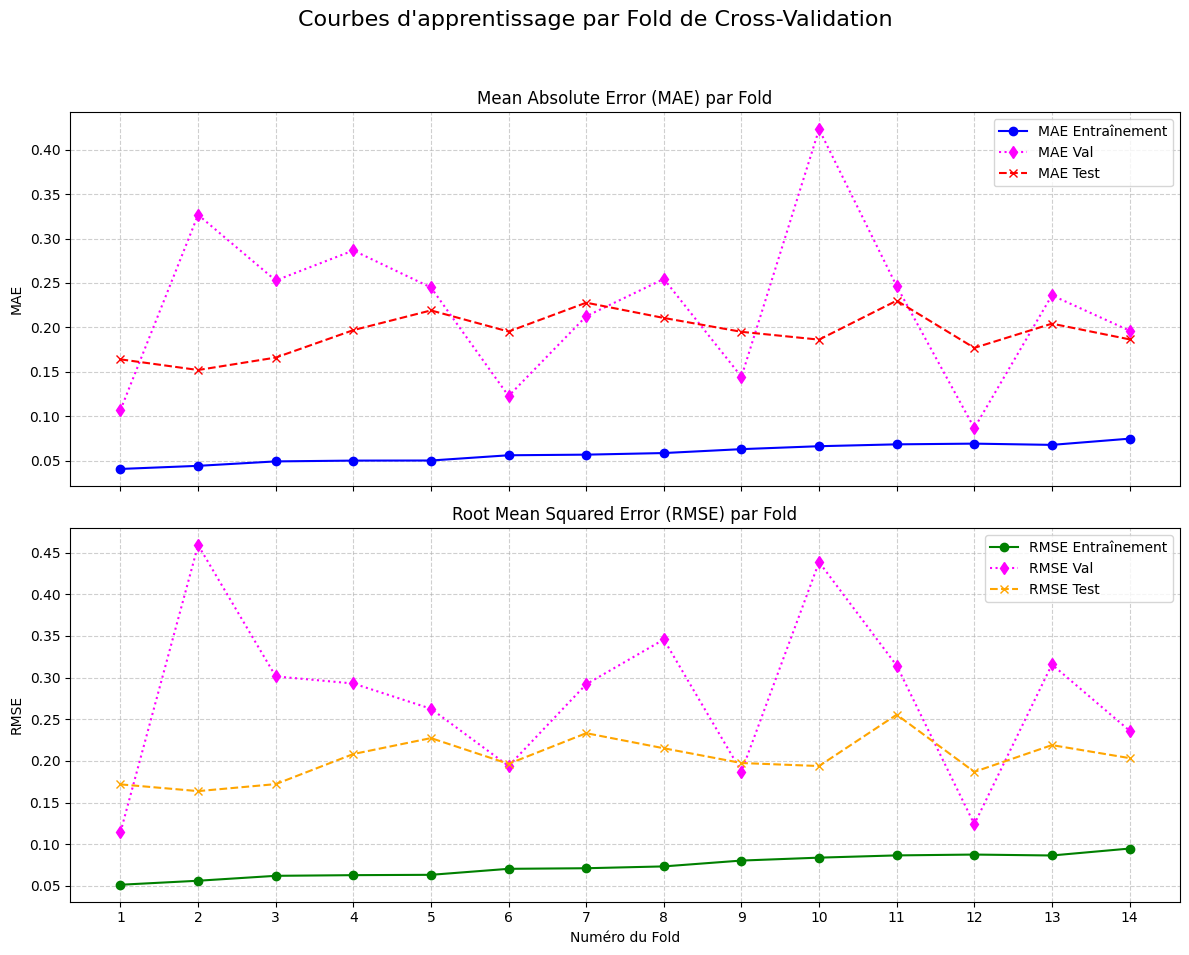

✅ Courbes d'apprentissage affichées.



In [62]:
plot_learning_curves(cv_2)

Avec la pluie --- 

Petite modif à la volée de load_piezo_bq



In [10]:
from hydrosense.database.bigquery import load_pem_bq
from hydrosense.preprocess.preprocessor import preprocess_week

df = load_pem_bq(DATA_CODE_PIEZO)

# WHERE bss_id = '{bss_id}'

PEM BSS001QHYH : 11821 lignes chargées


In [13]:
df_ww = preprocess_week(df)
df.columns



⭐️ Use case: preprocess
✅ preprocess() done — 1637 semaines | 9 colonnes



Index(['niveau_nappe_eau', 'RR_synth', 'TM_synth', 'FFM_synth'], dtype='object')

### Preprocess week

Nous avons besoin de changer la fonction de preprocess_week.



In [ ]:
from hydrosense.preprocess.preprocessor import preprocess_week

df_week = preprocess_week(df)
X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_slim)



⭐️ Use case: preprocess
✅ preprocess() done — 1637 semaines | 9 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 362 mois | Test : 3 mois



In [ ]:

# TRAIN / VAL Folding
splits_ml = get_folds(X_train_df.index, n_splits=15, min_train_years=3 , val_months_duration= 3)

# 2. Train — optimize=True pour GridSearchCV
model, history = train(X_train_df, y_train_df, optimize=False)

# 3. Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test_df, y_test_df)

cv_2 = [] # Pour stocker les métriques de chaque fold
all_pred_2 = pd.DataFrame() # Pour stocker toutes les prédictions pour la visualisation

for i, (train_idx, val_idx) in enumerate(splits_ml):

    print(f"\n--- Fold {i+1}/{len(splits_ml)} ---")

    X_train  = X.iloc[train_idx,:]
    y_train = y_target.iloc[train_idx]

    X_val = X.iloc[val_idx,:]
    y_val = y_target.iloc[val_idx]


    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    # options ??


    try:
        rf.fit(X_train, y_train,)
        forecast_rf = pd.Series(rf.predict(X_val), index=y_val.index)
        hindcast_rf = pd.Series(rf.predict(X_train), index=y_train.index)

        score_val = rf.score(X_val, y_val)
        score_train = rf.score(X_train, y_train)

        metrics_train = evaluate_model(rf, X_train, y_train)
        # mae_train = mean_absolute_error(y_train, hindcast_rf)
        # rmse_train = float(np.sqrt(
        #             mean_squared_error(y_train, hindcast_rf)
        #             ))
        # me_train = max_error(y_train, hindcast_rf)

        metrics_val = evaluate_model(rf, X_val, y_val)
        # mae_val = mean_absolute_error(y_val, forecast_rf)
        # rmse_val = float(np.sqrt(
        #             mean_squared_error(y_val, forecast_rf)
        #             ))
        # me_val  = max_error(y_val, forecast_rf)

        # rajouter des metrics. example :NSE - seasonal eror index

        # TODO : construct
        # metrics_test


        # TODO to construct cv results from the metrics_train val and test
        cv_2.append({
                'fold': i + 1,
                # 'train_start': train_data.index.min(), 'train_end': train_data.index.max(),
                'val_start': y_val.index.min(), 'val_end': y_val.index.max(),
                'r2_train' : score_train  , 'mae_train':mae_train, 'rmse_train':rmse_train,'me_train':me_train,
                'r2_val': score_val, 'mae_val':mae_val, 'rmse_val':rmse_val, 'me_val':me_val,
                'test_start': np.nan, 'test_end' : np.nan

            })

        # Stocker les prédictions pour une visualisation ultérieure
        fold_predictions = pd.DataFrame({
                'date': y_val.index,
                'actual': y_val,  'forecast': forecast_rf,
                'fold': i + 1
            })
        all_pred_2 = pd.concat([all_pred_2, fold_predictions])

    except Exception as e:
        print(f"  Erreur lors de l'entraînement ou de la prédiction pour le fold {i+1}: {e}")

#### Learning Curve

### 4.3 grid search pour trouver le meilleur random forest

## 5. XGBoost — Gradient Boosting

**XGBoost** est un algorithme de *gradient boosting* : il construit des arbres de décision
en séquence, chaque arbre corrigeant les erreurs du précédent.

Il surpasse souvent le Random Forest sur les séries temporelles car il est plus sensible
aux **relations non-linéaires** et aux **interactions entre features**.

La grille de paramètres testés :
- `n_estimators` : nombre d'arbres
- `learning_rate` : vitesse d'apprentissage (trop élevé = overfitting)
- `max_depth` : profondeur max de chaque arbre
- `subsample` / `colsample_bytree` : régularisation par sous-échantillonnage

In [ ]:
# 1. Préparation des colonnes (Lag)
df_w = pd.DataFrame(y_week)
df_w['semaine'] = df_w.index.isocalendar().week
df_w['lag_1'] = df_w['niveau_nappe_eau'].shift(1)
df_w['lag_2'] = df_w['niveau_nappe_eau'].shift(2)
df_w['lag_3'] = df_w['niveau_nappe_eau'].shift(3)
df_w['lag_4'] = df_w['niveau_nappe_eau'].shift(4)
df_w['lag_52'] = df_w['niveau_nappe_eau'].shift(52)


In [ ]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_w['moyenne_3w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_w['moyenne_6w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=6).mean()

# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_w = df_w.dropna()

X = df_w[['semaine', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w']]

y_target = df_w['niveau_nappe_eau']

# Split Train / Test
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [ ]:
X_train.head()

,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w
date_mesure,,,,,,,,
1995-02-05,5,14.321429,13.450000,13.261429,13.645714,13.690000,13.677619,13.619762
1995-02-12,6,13.988571,14.321429,13.450000,13.261429,13.732857,13.920000,13.701429
1995-02-19,7,13.705714,13.988571,14.321429,13.450000,13.657143,14.005238,13.728810
1995-02-26,8,13.908571,13.705714,13.988571,14.321429,13.384286,13.867619,13.772619
1995-03-05,9,13.895714,13.908571,13.705714,13.988571,13.217143,13.836667,13.878333


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)


Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}


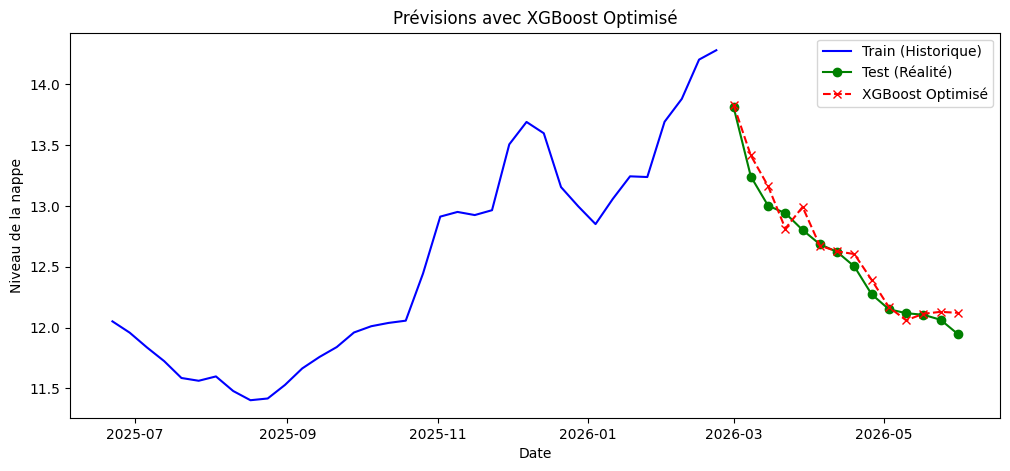

In [ ]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()